# Median Error Case — Best Model (Ridge + Phase Correction)

Validation waveform with median dephasing from `ridge_nh7_me5_mchi1_a1e-06+phase_corr`.

In [2]:
import os, pickle
import numpy as np
from scipy.interpolate import CubicSpline
from scipy.integrate import cumulative_trapezoid
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'serif', 'mathtext.fontset': 'cm', 'font.size': 10,
    'axes.labelsize': 13, 'axes.titlesize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True, 'axes.linewidth': 0.7,
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
    'legend.frameon': False, 'legend.fontsize': 9,
    'lines.linewidth': 0.8,
})

BASE = os.path.abspath('.')
RESULTS = os.path.join(BASE, 'results')

In [3]:
# Load model and data
with open(os.path.join(RESULTS, 'models', 'ridge_nh7_me5_mchi1_a1e-06', 'model.pkl'), 'rb') as f:
    model = pickle.load(f)

with open(os.path.join(RESULTS, 'validation_data.pkl'), 'rb') as f:
    val_data = pickle.load(f)

bc = model['bc']
coef_a = model['m_a'].coef_
coef_w = model['m_w'].coef_

# Find median dephasing case
dp = np.load(os.path.join(RESULTS, 'errors', 'ridge_nh7_me5_mchi1_a1e-06+phase_corr', 'val_dephasing.npy'))
med_idx = np.argsort(dp)[len(dp)//2]
d = val_data[med_idx]

print(f'Median case: idx={med_idx}, dphi={dp[med_idx]:.6f}')
print(f'  q={d["q"]:.2f}, chi1={d["chi1"]:.3f}, chi2={d["chi2"]:.3f}, e0={d["e0"]:.4f}')
print(f'  nu={d["nu"]:.4f}, chi_S={d["chi_S"]:.4f}, chi_A={d["chi_A"]:.4f}, chi_eff={d["chi_eff"]:.4f}')

Median case: idx=30, dphi=0.144711
  q=2.80, chi1=-0.090, chi2=-0.265, e0=0.2881
  nu=0.1938, chi_S=-0.1774, chi_A=0.0871, chi_eff=-0.1361


/Users/tousifislam/miniforge3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Ridge from version 1.7.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [4]:
# ---- Ansatz ----
def h22_ecc_ansatz(x, e, zeta, nu):
    e2 = e*e; e3 = e2*e
    eiz = np.exp(1j*zeta); emiz = np.exp(-1j*zeta)
    leading = (4.0 + 2.0*e2*eiz**2 + e*emiz + 5.0*e*eiz) / (4.0*(1.0-e2))
    tc = e*(26.0*nu/7.0 - 559.0/84.0)
    tem2 = e*np.exp(-2j*zeta)*(15.0*nu/14.0 - 95.0/168.0)
    tem3 = e2*np.exp(-3j*zeta)*(9.0*nu/56.0 + 1.0/112.0)
    te3 = e2*np.exp(3j*zeta)*(nu/8.0 - 49.0/48.0)
    te2 = np.exp(2j*zeta)*(e3*(6.0*nu/7.0-41.0/21.0)+e*(nu/14.0-153.0/56.0))
    tem = emiz*(e2*(7.0*nu/8.0-59.0/48.0)+27.0*nu/14.0-23.0/14.0)
    tei = eiz*(e2*(143.0*nu/56.0-2071.0/336.0)+nu/14.0-13.0/7.0)
    curly = tc+tem3+te3+tem2+te2+tem+tei
    return leading + (x*e)/(1.0-e2)**2 * curly

# ---- Basis construction ----
def build_basis(e, z, x, nu, chi_S, chi_A, max_e, max_x, max_nu, max_chi, n_harm):
    features = []
    for a in range(1, max_e+1):
        for b in range(max_x+1):
            for c in range(max_nu+1):
                for d_s in range(max_chi+1):
                    for d_a in range(max_chi+1):
                        if a+b+c+d_s+d_a > max_e+3:
                            continue
                        base = e**a * x**b * nu**c * chi_S**d_s * chi_A**d_a
                        features.append(base)
                        for k in range(1, n_harm+1):
                            features.append(base*np.cos(k*z))
                            features.append(base*np.sin(k*z))
    return np.column_stack(features)

# ---- Phase correction ----
def poly_phase_correction(t_d, phi_pred, phi_ecc, order=5):
    dphi = phi_pred - phi_ecc
    T = (t_d - t_d[0]) / max(t_d[-1] - t_d[0], 1.0)
    A = np.column_stack([T**k for k in range(1, order+1)])
    c = np.linalg.lstsq(A, dphi - dphi[0], rcond=None)[0]
    return phi_pred - A @ c

# ---- Smooth taper ----
def smooth_taper(t, ts=-50.0, te=0.0):
    w = np.ones_like(t)
    m = (t >= ts) & (t <= te)
    w[m] = 0.5*(1+np.cos(np.pi*(t[m]-ts)/(te-ts)))
    w[t > te] = 0
    return w

In [5]:
# ---- Predict modulations ----
n = min(len(d['delta_xi_amp']), len(d['delta_xi_omega']))
e = np.clip(d['e'][:n], 1e-6, 0.95)
x = np.clip(d['x'][:n], 1e-6, 0.5)
z = d['zeta'][:n]
t = d['t'][:n]

# Ansatz
xi_amp_ans = np.abs(h22_ecc_ansatz(x, e, z, d['nu'])) - 1.0
xi_omg_ans = xi_amp_ans / 0.9

# Ridge residual
X = build_basis(e, z, x, np.full(n, d['nu']), np.full(n, d['chi_S']),
                np.full(n, d['chi_A']), **bc)
dxi_a = X @ coef_a
dxi_w = X @ coef_w

# Total predicted modulations
xi_amp_pred = xi_amp_ans + dxi_a
xi_omg_pred = xi_omg_ans + dxi_w

# SEOB reference
xi_amp_ref = d['xi_amp'][:n]
xi_omg_ref = d['xi_omega'][:n]

print(f'Points: {n}')

Points: 24011


In [6]:
# ---- Reconstruct waveforms ----
dt_r = 0.1
t_d = np.arange(d['t'][0], d['t'][-1], dt_r)

h_ecc_d = CubicSpline(d['t'], np.real(d['h_ecc']))(t_d) + \
          1j*CubicSpline(d['t'], np.imag(d['h_ecc']))(t_d)
h_cir_d = CubicSpline(d['t'], np.real(d['h_cir']))(t_d) + \
          1j*CubicSpline(d['t'], np.imag(d['h_cir']))(t_d)

phi_cir = np.unwrap(np.angle(h_cir_d))
omega_cir = np.gradient(phi_cir, dt_r)
phi_ecc = np.unwrap(np.angle(h_ecc_d))
taper = smooth_taper(t_d)

# --- Best model (Ridge + phase corr) ---
xi_a_d = np.interp(t_d, t, xi_amp_pred) * taper
xi_w_d = np.interp(t_d, t, xi_omg_pred) * taper

A_p = np.abs(h_cir_d) * (1.0 + xi_a_d)
pp = cumulative_trapezoid(omega_cir*(1.0+xi_w_d), dx=dt_r, initial=0.0)
pp += phi_ecc[0] - pp[0]
pp = poly_phase_correction(t_d, pp, phi_ecc, order=5)
h_pred = A_p * np.exp(1j * pp)

h_ref = h_ecc_d * np.exp(-1j*np.angle(h_ecc_d[0]))
h_mod = h_pred * np.exp(-1j*np.angle(h_pred[0]))
phi_r = np.unwrap(np.angle(h_ref))
phi_m = np.unwrap(np.angle(h_mod))
phi_m -= (phi_m[0] - phi_r[0])
dephasing = phi_m - phi_r

# --- Ansatz only ---
xi_a_ans_d = np.interp(t_d, t, xi_amp_ans) * taper
xi_w_ans_d = np.interp(t_d, t, xi_omg_ans) * taper

A_ans = np.abs(h_cir_d) * (1.0 + xi_a_ans_d)
pp_ans = cumulative_trapezoid(omega_cir*(1.0+xi_w_ans_d), dx=dt_r, initial=0.0)
pp_ans += phi_ecc[0] - pp_ans[0]
h_ans = A_ans * np.exp(1j * pp_ans)

h_ans_aligned = h_ans * np.exp(-1j*np.angle(h_ans[0]))
phi_ans = np.unwrap(np.angle(h_ans_aligned))
phi_ans -= (phi_ans[0] - phi_r[0])
dephasing_ans = phi_ans - phi_r

print(f'Max |dephasing| model  = {np.max(np.abs(dephasing)):.6f} rad')
print(f'Max |dephasing| ansatz = {np.max(np.abs(dephasing_ans)):.4f} rad')

Max |dephasing| model  = 0.144711 rad
Max |dephasing| ansatz = 24.0765 rad


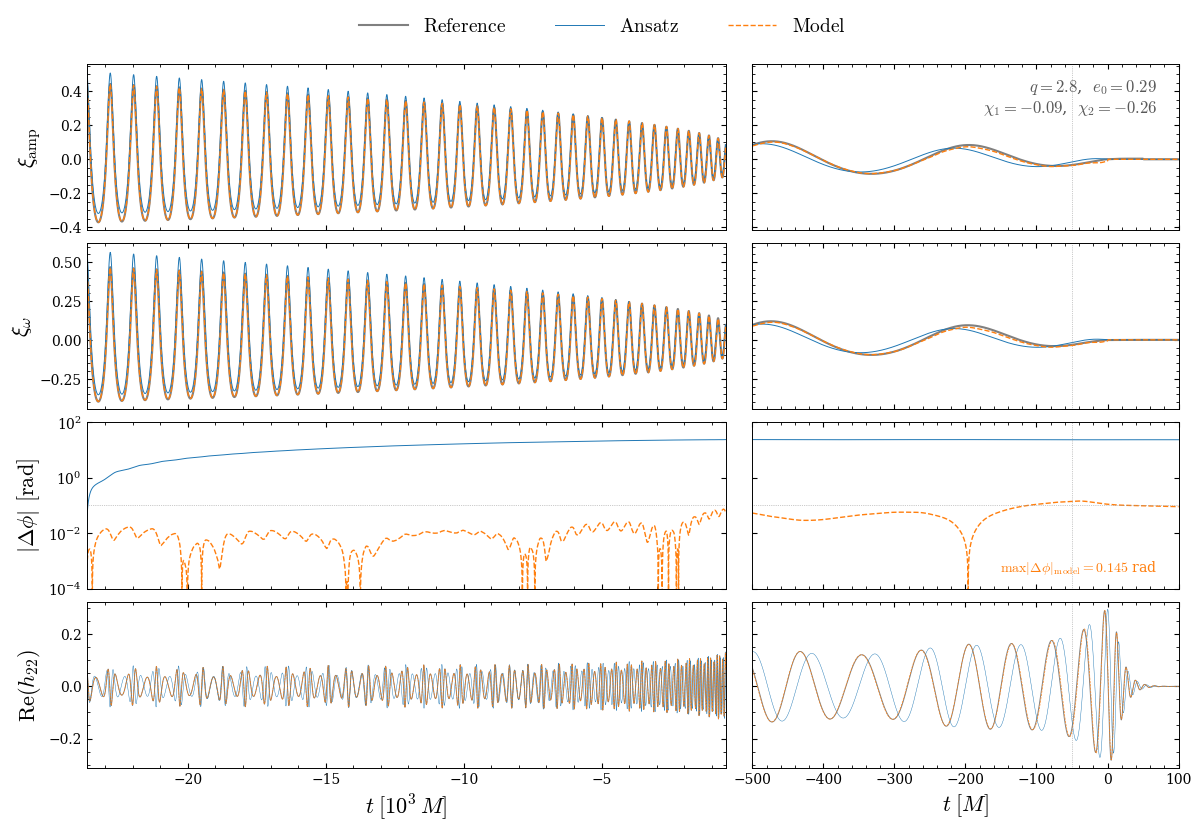

Saved median_error.pdf


In [10]:
# ========== FOUR-PANEL, SPLIT-TIME FIGURE ==========
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# PRD-style colors
c_ref = 'gray' #'black'
c_ans = 'C0' #'#0055AA'
c_mod = 'C1' #'#CC0000'

# Uniform line styles across ALL panels
# Reference: solid, thickest
# Ansatz: solid, medium
# Model: dashed, medium
ls_ref = '-';  lw_ref = 1.5
ls_ans = '-';  lw_ans = 0.7
ls_mod = '--'; lw_mod = 1

# Panel 4 (h22) uses scaled-down widths (dense oscillations)
# but same ratios and same linestyles
h_scale = 0.45  # multiply all lw by this for the waveform panel

t_split = -500.0
t_min = t[0]

fig = plt.figure(figsize=(12, 8))
gs = GridSpec(4, 2, figure=fig, width_ratios=[0.6, 0.4],
              left=0.07, right=0.98, top=0.94, bottom=0.06,
              hspace=0.08, wspace=0.05)

ax_pairs = []
for row in range(4):
    if row == 2:
        ax_l = fig.add_subplot(gs[row, 0])
        ax_r = fig.add_subplot(gs[row, 1])
    else:
        ax_l = fig.add_subplot(gs[row, 0])
        ax_r = fig.add_subplot(gs[row, 1], sharey=ax_l)
    plt.setp(ax_r.get_yticklabels(), visible=False)
    ax_pairs.append((ax_l, ax_r))
    if row < 3:
        plt.setp(ax_l.get_xticklabels(), visible=False)
        plt.setp(ax_r.get_xticklabels(), visible=False)

# Strict xlims
for row in range(4):
    ax_pairs[row][0].set_xlim(t_min/1e3, t_split/1e3)
    ax_pairs[row][1].set_xlim(-500, 100)

# Masks
m_l  = t < t_split
m_r  = (t >= t_split) & (t <= 100)
m_l_d = t_d < t_split
m_r_d = (t_d >= t_split) & (t_d <= 100)

# ---- Legend at top ----
legend_handles = [
    Line2D([0],[0], color=c_ref, lw=lw_ref, ls=ls_ref, label='$\\rm Reference$'),
    Line2D([0],[0], color=c_ans, lw=lw_ans, ls=ls_ans, label='$\\rm Ansatz$'),
    Line2D([0],[0], color=c_mod, lw=lw_mod, ls=ls_mod, label='$\\rm Model$'),
]
fig.legend(handles=legend_handles, loc='upper center', ncol=3, fontsize=14,
           frameon=False,
           bbox_to_anchor=(0.5, 1.02), handlelength=2.5, columnspacing=2.5)

# Helper to plot a triad with consistent style
def plot_triad(ax, t_p, y_ref, y_ans, y_mod, scale=1.0):
    ax.plot(t_p, y_ref, color=c_ref, lw=lw_ref*scale, ls=ls_ref)
    ax.plot(t_p, y_ans, color=c_ans, lw=lw_ans*scale, ls=ls_ans)
    ax.plot(t_p, y_mod, color=c_mod, lw=lw_mod*scale, ls=ls_mod)

# ---- Panel 1: xi_amp ----
for ax, mask in zip(ax_pairs[0], [m_l, m_r]):
    t_p = t[mask] / 1e3 if mask is m_l else t[mask]
    plot_triad(ax, t_p, xi_amp_ref[mask], xi_amp_ans[mask], xi_amp_pred[mask])
ax_pairs[0][0].set_ylabel('$\\xi_{\\rm amp}$', fontsize=16)

# ---- Panel 2: xi_omega ----
for ax, mask in zip(ax_pairs[1], [m_l, m_r]):
    t_p = t[mask] / 1e3 if mask is m_l else t[mask]
    plot_triad(ax, t_p, xi_omg_ref[mask], xi_omg_ans[mask], xi_omg_pred[mask])
ax_pairs[1][0].set_ylabel('$\\xi_\\omega$', fontsize=16)

# ---- Panel 3: |Dephasing| (log scale) ----
# Only ansatz and model dephasing (no reference — reference is zero by definition)
for ax, mask in zip(ax_pairs[2], [m_l_d, m_r_d]):
    t_p = t_d[mask] / 1e3 if mask is m_l_d else t_d[mask]
    ax.semilogy(t_p, np.abs(dephasing_ans[mask]) + 1e-15,
                color=c_ans, lw=lw_ans, ls=ls_ans)
    ax.semilogy(t_p, np.abs(dephasing[mask]) + 1e-15,
                color=c_mod, lw=lw_mod, ls=ls_mod)
    ax.axhline(0.1, color='0.6', lw=0.5, ls=':')
    ax.set_ylim(1e-4, 1e2)
ax_pairs[2][0].set_ylabel('$|\\Delta\\phi|$ $\\rm [rad]$', fontsize=16)
ax_pairs[2][1].text(0.95, 0.07,
    f'$\\max|\\Delta\\phi|_{{\\rm model}} = {np.max(np.abs(dephasing)):.3f}$ rad',
    transform=ax_pairs[2][1].transAxes, fontsize=10, ha='right', va='bottom',
    color=c_mod)

# ---- Panel 4: Re(h22) — same styles, scaled linewidths ----
for ax, mask in zip(ax_pairs[3], [m_l_d, m_r_d]):
    t_p = t_d[mask] / 1e3 if mask is m_l_d else t_d[mask]
    plot_triad(ax, t_p, np.real(h_ref[mask]),
               np.real(h_ans_aligned[mask]), np.real(h_mod[mask]),
               scale=h_scale)
ax_pairs[3][0].set_ylabel('$\\mathrm{Re}(h_{22})$', fontsize=16)
ax_pairs[3][0].set_xlabel('$t\\;[10^3\\,M]$', fontsize=16)
ax_pairs[3][1].set_xlabel('$t\\;[M]$', fontsize=16)

# Taper onset on right panels
for row in range(4):
    ax_pairs[row][1].axvline(-50, color='0.6', lw=0.5, ls=':')

# Parameter annotation
ax_pairs[0][1].text(0.95, 0.92,
    f'$q={d["q"]:.1f}$,  $e_0={d["e0"]:.2f}$\n'
    f'$\\chi_1={d["chi1"]:.2f}$,  $\\chi_2={d["chi2"]:.2f}$',
    transform=ax_pairs[0][1].transAxes, fontsize=12, ha='right', va='top',
    color='0.35')

plt.savefig('median_error.pdf', dpi=300, bbox_inches='tight', pad_inches=0.02)
plt.savefig('median_error.png', dpi=150, bbox_inches='tight', pad_inches=0.02)
plt.show()
print('Saved median_error.pdf')

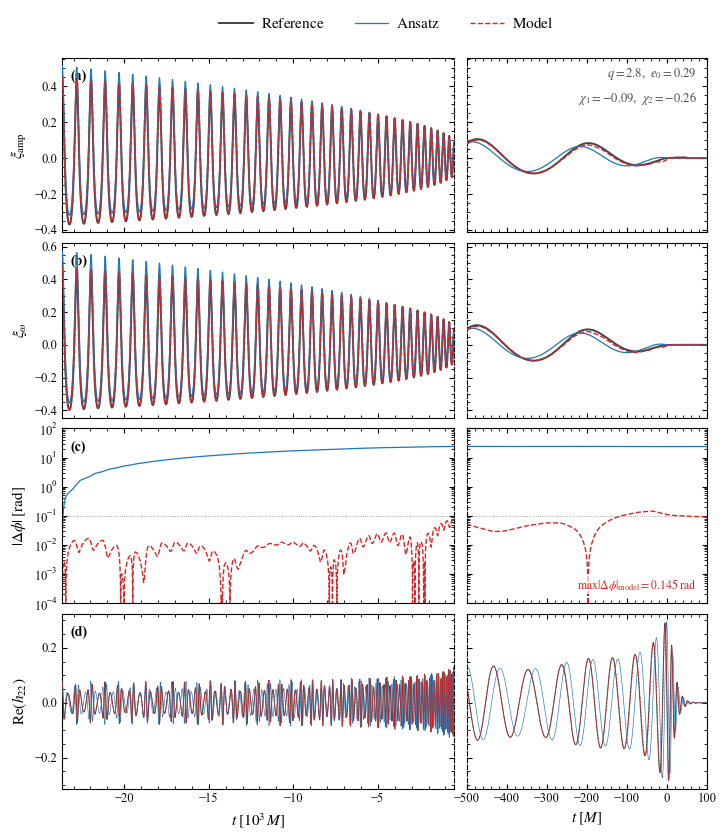

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import numpy as np

# ── Typography & style ───────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset':  'stix',
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.top':         True,
    'ytick.right':       True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'axes.linewidth':    0.8,
})

# ── Colors & line styles ─────────────────────────────────────────
c_ref = '#444444'
c_ans = '#1f77b4'   # muted blue
c_mod = '#d62728'   # muted red

ls_ref = '-';  lw_ref = 1.4
ls_ans = '-';  lw_ans = 0.9
ls_mod = '--'; lw_mod = 1.0
h_scale = 0.5

t_split = -500.0
t_min   = t[0]

# ── Layout ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(7.2, 8.5))   # Science two-column: 7.2 in wide
gs  = GridSpec(
    4, 2, figure=fig,
    width_ratios=[0.62, 0.38],
    left=0.09, right=0.985,
    top=0.93,  bottom=0.07,
    hspace=0.06, wspace=0.04,
)

ax_pairs = []
for row in range(4):
    ax_l = fig.add_subplot(gs[row, 0])
    ax_r = fig.add_subplot(gs[row, 1], sharey=ax_l)
    plt.setp(ax_r.get_yticklabels(), visible=False)
    if row < 3:
        plt.setp(ax_l.get_xticklabels(), visible=False)
        plt.setp(ax_r.get_xticklabels(), visible=False)
    ax_pairs.append((ax_l, ax_r))

# ── xlims ────────────────────────────────────────────────────────
for ax_l, ax_r in ax_pairs:
    ax_l.set_xlim(t_min / 1e3, t_split / 1e3)
    ax_r.set_xlim(-500, 100)

# ── Masks ────────────────────────────────────────────────────────
m_l   = t   < t_split
m_r   = (t   >= t_split) & (t   <= 100)
m_l_d = t_d < t_split
m_r_d = (t_d >= t_split) & (t_d <= 100)

# ── Shared legend ────────────────────────────────────────────────
legend_handles = [
    Line2D([0],[0], color=c_ref, lw=lw_ref, ls=ls_ref, label=r'$\rm Reference$'),
    Line2D([0],[0], color=c_ans, lw=lw_ans, ls=ls_ans, label=r'$\rm Ansatz$'),
    Line2D([0],[0], color=c_mod, lw=lw_mod, ls=ls_mod, label=r'$\rm Model$'),
]
fig.legend(
    handles=legend_handles,
    loc='upper center', ncol=3, fontsize=11,
    frameon=False, framealpha=0.9, edgecolor='0.8',
    bbox_to_anchor=(0.54, 0.995),
    handlelength=2.2, columnspacing=2.0, handletextpad=0.5,
)

# ── Panel labels (a–d) ───────────────────────────────────────────
panel_labels = ['(a)', '(b)', '(c)', '(d)']
for row, (ax_l, _) in enumerate(ax_pairs):
    ax_l.text(0.02, 0.93, panel_labels[row],
              transform=ax_l.transAxes, fontsize=10,
              fontweight='bold', va='top', ha='left')

# ── Vertical split divider ───────────────────────────────────────
for ax_l, ax_r in ax_pairs:
    ax_l.spines['right'].set_linestyle((0, (4, 2)))
    ax_r.spines['left'].set_linestyle((0, (4, 2)))

# ── Helper ───────────────────────────────────────────────────────
def plot_triad(ax, t_p, y_ref, y_ans, y_mod, scale=1.0):
    ax.plot(t_p, y_ref, color=c_ref, lw=lw_ref*scale, ls=ls_ref, zorder=2)
    ax.plot(t_p, y_ans, color=c_ans, lw=lw_ans*scale, ls=ls_ans, zorder=3)
    ax.plot(t_p, y_mod, color=c_mod, lw=lw_mod*scale, ls=ls_mod, zorder=4)

# ── Panel 1: xi_amp ──────────────────────────────────────────────
for ax, mask in zip(ax_pairs[0], [m_l, m_r]):
    t_p = t[mask] / 1e3 if mask is m_l else t[mask]
    plot_triad(ax, t_p, xi_amp_ref[mask], xi_amp_ans[mask], xi_amp_pred[mask])
ax_pairs[0][0].set_ylabel(r'$\xi_{\rm amp}$')

# ── Panel 2: xi_omega ────────────────────────────────────────────
for ax, mask in zip(ax_pairs[1], [m_l, m_r]):
    t_p = t[mask] / 1e3 if mask is m_l else t[mask]
    plot_triad(ax, t_p, xi_omg_ref[mask], xi_omg_ans[mask], xi_omg_pred[mask])
ax_pairs[1][0].set_ylabel(r'$\xi_\omega$')

# ── Panel 3: |Dephasing| ─────────────────────────────────────────
for ax, mask in zip(ax_pairs[2], [m_l_d, m_r_d]):
    t_p = t_d[mask] / 1e3 if mask is m_l_d else t_d[mask]
    ax.semilogy(t_p, np.abs(dephasing_ans[mask]) + 1e-15,
                color=c_ans, lw=lw_ans, ls=ls_ans)
    ax.semilogy(t_p, np.abs(dephasing[mask])     + 1e-15,
                color=c_mod, lw=lw_mod, ls=ls_mod)
    ax.axhline(0.1, color='0.55', lw=0.6, ls=':', zorder=1)
    ax.set_ylim(1e-4, 1e2)
ax_pairs[2][0].set_ylabel(r'$|\Delta\phi|\;[\mathrm{rad}]$')
ax_pairs[2][1].text(
    0.96, 0.06,
    rf'$\max|\Delta\phi|_{{\rm model}} = {np.max(np.abs(dephasing)):.3f}$ rad',
    transform=ax_pairs[2][1].transAxes, fontsize=8.5,
    ha='right', va='bottom', color=c_mod,
    bbox=dict(fc='white', ec='none', alpha=0.7, pad=1),
)

# ── Panel 4: Re(h22) ─────────────────────────────────────────────
for ax, mask in zip(ax_pairs[3], [m_l_d, m_r_d]):
    t_p = t_d[mask] / 1e3 if mask is m_l_d else t_d[mask]
    plot_triad(ax, t_p,
               np.real(h_ref[mask]),
               np.real(h_ans_aligned[mask]),
               np.real(h_mod[mask]),
               scale=h_scale)
ax_pairs[3][0].set_ylabel(r'$\mathrm{Re}(h_{22})$')
ax_pairs[3][0].set_xlabel(r'$t\;[10^3\,M]$')
ax_pairs[3][1].set_xlabel(r'$t\;[M]$')

# ── Taper onset & merger markers ─────────────────────────────────
# for ax_l, ax_r in ax_pairs:
#     ax_r.axvline(-50, color='0.55', lw=0.6, ls=':', zorder=1)
#     ax_r.axvline(0,   color='0.75', lw=0.5, ls='--', zorder=0)

# ── Parameter annotation ─────────────────────────────────────────
ax_pairs[0][1].text(
    0.96, 0.95,
    f'$q={d["q"]:.1f}$,  $e_0={d["e0"]:.2f}$\n'
    f'$\\chi_1={d["chi1"]:.2f}$,  $\\chi_2={d["chi2"]:.2f}$',
    transform=ax_pairs[0][1].transAxes, fontsize=9,
    ha='right', va='top', color='0.3',
    linespacing=1.6,
)

# ── Save ─────────────────────────────────────────────────────────
plt.savefig('median_error.pdf', dpi=300, bbox_inches='tight', pad_inches=0.02)
plt.savefig('median_error.png', dpi=200, bbox_inches='tight', pad_inches=0.02)
plt.show()